In [1]:
import pandas as pd

sales = pd.read_csv("../dataset/sales.csv")

sales.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [2]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  customer_gender

In [3]:
sales.drop_duplicates(inplace=True)
sales.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [5]:
sales['order_date'] = pd.to_datetime(
    sales['order_date'],
    dayfirst=True
)

In [6]:
monthly_sales = sales.groupby(
    sales['order_date'].dt.month
)['total_amount'].sum()

monthly_sales

order_date
1     442156.30
2     443352.17
3     487523.09
4     528620.69
5     513402.69
6     482931.66
7     502962.90
8     456421.70
9     461857.67
10    521434.01
11    490858.95
12    533771.22
Name: total_amount, dtype: float64

In [7]:
top_products = sales.groupby(
    'product_id'
)['quantity'].sum().sort_values(
    ascending=False
)

top_products.head()

product_id
P222065    14
P211187    13
P247881    13
P234626    12
P242018    11
Name: quantity, dtype: int64

In [8]:
category_sales = sales.groupby(
    'category'
)['total_amount'].sum()

category_sales

category
Beauty          153019.38
Electronics    3319206.50
Fashion         471545.80
Grocery          82000.51
Home           1077681.52
Sports          629825.54
Toys            132013.80
Name: total_amount, dtype: float64

In [9]:
returned_orders = sales[
    sales['returned'] == 'Yes'
]

returned_orders.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
19,O100019,C10130,P248629,Fashion,50.52,0.00,1,Credit Card,2024-10-10,3,North,Yes,50.52,6.20,11.48,56,Male
67,O100067,C10600,P221990,Fashion,20.91,0.00,1,UPI,2024-02-14,4,North,Yes,20.91,4.04,3.28,50,Male
100,O100100,C14798,P236240,Sports,17.35,0.10,1,Debit Card,2025-02-25,5,West,Yes,15.62,4.69,-0.00,41,Male
124,O100124,C14887,P220387,Electronics,537.39,0.15,1,PayPal,2024-02-16,4,Central,Yes,456.78,9.40,45.41,28,Female
126,O100126,C16360,P237391,Toys,16.78,0.00,2,Credit Card,2024-10-02,4,South,Yes,33.56,5.18,8.24,34,Female


In [10]:
arpu = (
    sales['total_amount'].sum()
    /
    sales['customer_id'].nunique()
)

print(arpu)

742.1603251929647


In [11]:
aov = sales['total_amount'].mean()

purchase_frequency = (
    len(sales)
    /
    sales['customer_id'].nunique()
)

clv = aov * purchase_frequency

print(clv)

742.1603251929646


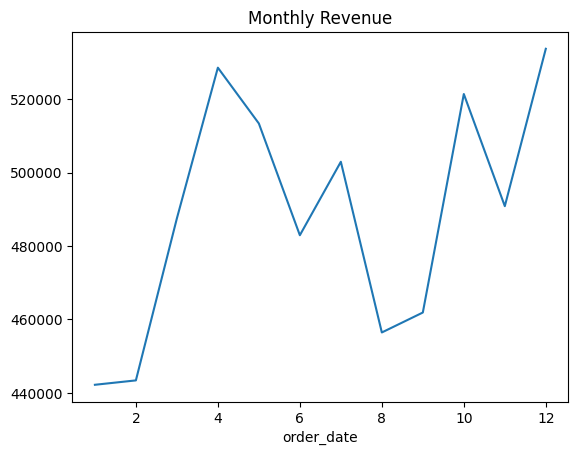

In [12]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line')

plt.title("Monthly Revenue")

plt.show()

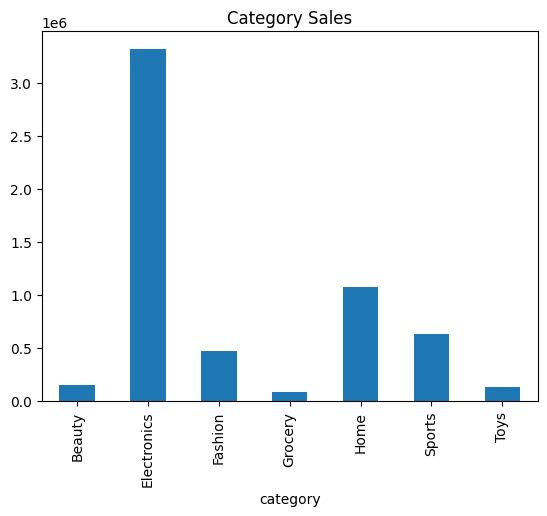

In [13]:
category_sales.plot(kind='bar')

plt.title("Category Sales")

plt.show()

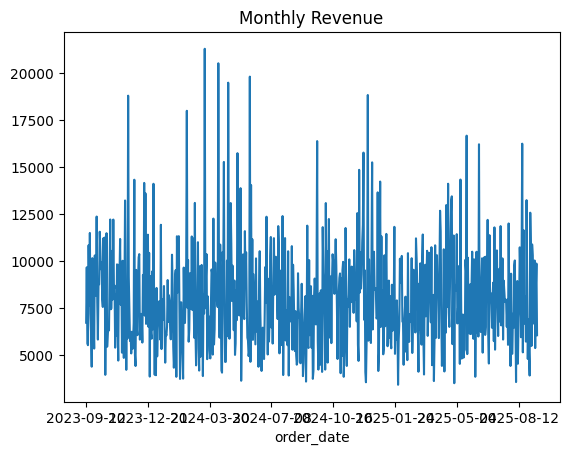

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
sales = pd.read_csv("../dataset/sales.csv")

# Monthly sales
monthly_sales = sales.groupby(
    sales['order_date']
)['total_amount'].sum()

# Top products
top_products = sales.groupby(
    'product_id'
)['quantity'].sum().sort_values(
    ascending=False
)

# Category sales
category_sales = sales.groupby(
    'category'
)['total_amount'].sum()

# Save CSV files
sales.to_csv("../outputs/cleaned_sales.csv", index=False)

monthly_sales.to_csv("../outputs/monthly_sales.csv")

top_products.to_csv("../outputs/top_products.csv")

category_sales.to_csv("../outputs/category_sales.csv")

# Save graph
monthly_sales.plot(kind='line')

plt.title("Monthly Revenue")

plt.savefig("../outputs/monthly_revenue.png")

plt.show()